In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Sample data
x=np.array([1,2,3,4,5]) 
# Target values 
y=np.array([2,3,5,7,11])

simple data plotting

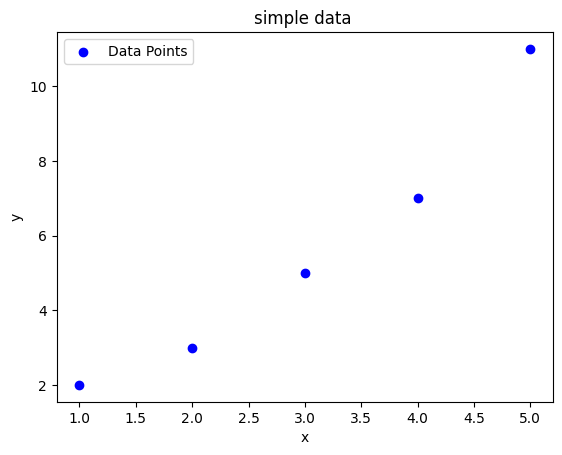

In [3]:
plt.scatter(x, y, color='blue', label='Data Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('simple data ')
plt.legend()
plt.show()




model parameters

In [4]:
# Initialize parameters
# theta0=0.8
# theta1=3
theta0=0
theta1=1.5

In [5]:
import numpy as np

def predict(x, theta0, theta1):
    m = len(x)
    predictions = np.zeros(m)    # initialize an array of size m
    for i in range(m):
        predictions[i] = theta0 + theta1 * x[i]
    return predictions


In [6]:
print(predict(x, theta0, theta1))

[1.5 3.  4.5 6.  7.5]


prediction function plotting 

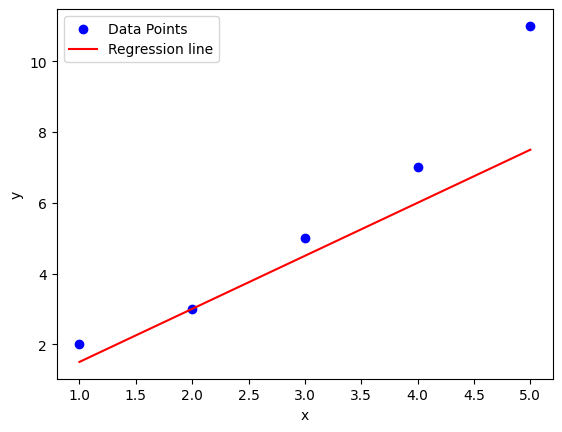

In [43]:
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, predict(x, theta0, theta1), color='red', label='Regression line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


cost function

In [44]:
def compute_cost(x, y, theta0, theta1):
    m = len(x)
    total_error = 0
    for i in range(m):
        predict = np.dot(x[i], theta1) + theta0   # prediction for one sample
        error = predict - y[i]                   # difference
        total_error += error ** 2                # accumulate squared error
    cost = total_error / (2 * m)                 # average (with 1/2m)
    return cost


In [45]:

print("Manual loop cost =", compute_cost(x, y, theta0, theta1))

Manual loop cost = 1.375


In [46]:
def plot_regression(x, y, theta0, theta1):
    plt.scatter(x, y, color='blue', label="Data points")            # scatter plot of real data
    plt.plot(x, predict(x, theta0, theta1), color='red', label="Regression line")  # regression line
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


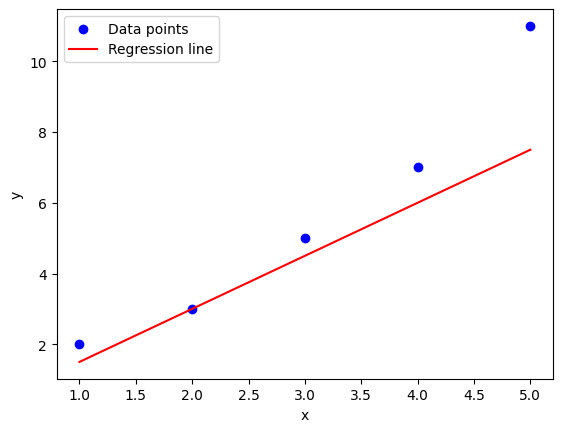

In [47]:
plot_regression(x, y, theta0, theta1)

gradients

In [48]:
def gradients(x, y, theta0, theta1):
    m = len(x)
    grad0 = 0
    grad1 = 0
    for i in range(m):
        predict = np.dot(x[i], theta1) + theta0   # prediction for one sample
        error = predict - y[i]                   # difference
        grad0 += error                           # accumulate gradient for theta0
        grad1 += error * x[i]                    # accumulate gradient for theta1
    grad0 /= m                                  # average gradient for theta0
    grad1 /= m                                  # average gradient for theta1
    return grad0, grad1

In [49]:
show_value=gradients(x, y, theta0, theta1)
print("Gradients: dJ/dtheta0 =", show_value[0], ", dJ/dtheta1 =", show_value[1])



Gradients: dJ/dtheta0 = -1.1 , dJ/dtheta1 = -4.7


In [ ]:
def gradient_descent(x, y, theta0, theta1, learning_rate=0.01, iterations=1000):
    history = []   # store (theta0, theta1, cost) at each step
    for _ in range(iterations):
        grad0, grad1 = gradients(x, y, theta0, theta1)
        theta0 -= learning_rate * grad0
        theta1 -= learning_rate * grad1
        cost = compute_cost(x, y, theta0, theta1)
        history.append((theta0, theta1, cost))
    return theta0, theta1, history


Final parameters: -0.06377100693494528 1.9406781426952209
Final cost: 0.3597714809131653


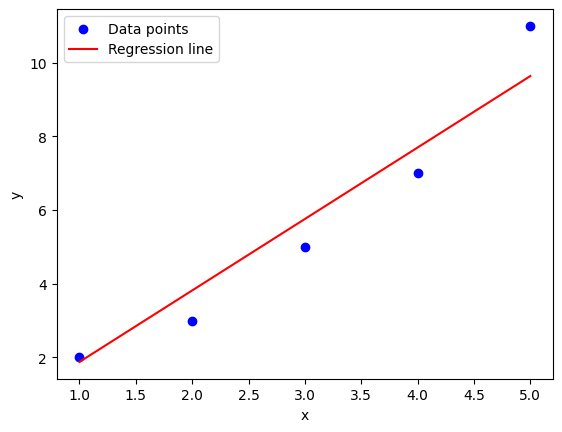

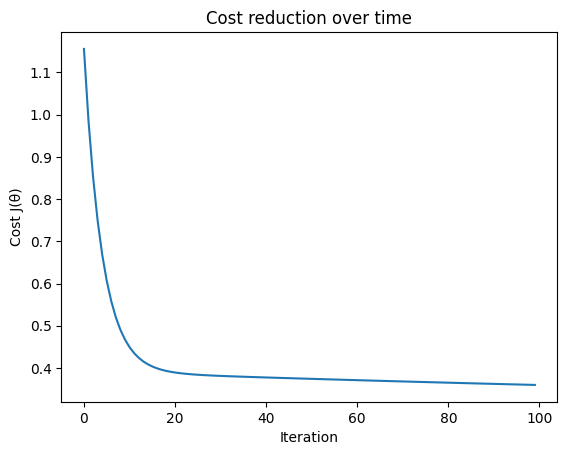

In [51]:
theta0, theta1, history = gradient_descent(x, y, theta0, theta1, learning_rate=0.01, iterations=100)

print("Final parameters:", theta0, theta1)
print("Final cost:", history[-1][2])

# Plot final line
plot_regression(x, y, theta0, theta1)

# Plot cost over time
costs = [c for (_, _, c) in history]
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Cost J(θ)")
plt.title("Cost reduction over time")
plt.show()

testing model

In [52]:
new_x = 8  # Example new input
predicted_y = predict(np.array([new_x]), theta0, theta1)[0]
print(f"Predicted y for x={new_x}: {predicted_y}")

Predicted y for x=8: 15.461654134626821


vectorization form of a code 


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1️⃣ Hypothesis function: h = X * theta
# ------------------------------------------------
def hypothesis(X, theta):
    return X.dot(theta)

In [13]:
# ------------------------------------------------
# 2️⃣ Cost function: Mean Squared Error (MSE)
# ------------------------------------------------
def cost(X, y, theta):
    m = len(y)
    h = hypothesis(X, theta)
    return (1 / (2 * m)) * np.sum((h - y) ** 2)

#

In [14]:
# print(predict(X_b, np.array([0.8, 3])))  # Example prediction

In [21]:
 
# 3️⃣ Gradient computation (vectorized)
# ------------------------------------------------
def gradient(X, y, theta):
    m = len(y)
    h = hypothesis(X, theta)
    return (1 / m) * X.T.dot(h - y)


In [22]:
# print(compute_cost(X_b, y, np.array([0.8, 3])))

In [23]:
# 4️⃣ Gradient Descent optimization
# ------------------------------------------------
def gradient_descent(X, y, theta, alpha, iterations):
    cost_history = []
    for i in range(iterations):
        theta = theta - alpha * gradient(X, y, theta)
        cost_history.append(cost(X, y, theta))
    return theta, cost_history



In [24]:
# print(gradients(X_b, y, np.array([0.8, 3])))

In [25]:
# ------------------------------------------------
# 5️⃣ MAIN SCRIPT
# ------------------------------------------------
# Sample data
x = np.array([3,5,7,9]).reshape(-1, 1)
y = np.array([12, 14, 16, 20]).reshape(-1, 1)

# Add bias term (column of 1s)
X = np.hstack((np.ones((x.shape[0], 1)), x))

# Initialize parameters
theta = np.zeros((2, 1))
alpha = 0.01
iterations = 1000

# Train model
final_theta, cost_history = gradient_descent(X, y, theta, alpha, iterations)

# Results
print("Final parameters (θ0, θ1):", final_theta.ravel())
print("Final cost:", cost_history[-1])

Final parameters (θ0, θ1): [5.47393914 1.62671636]
Final cost: 0.4521738548070756


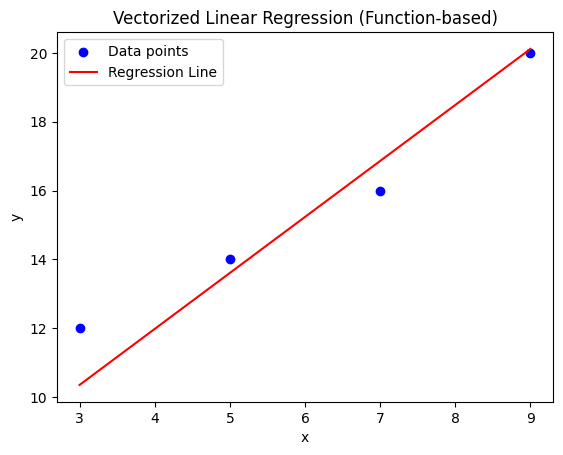

In [26]:

# 6️⃣ Plot regression line
# ------------------------------------------------
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, hypothesis(X, final_theta), color='red', label='Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Vectorized Linear Regression (Function-based)')
plt.legend()
plt.show()

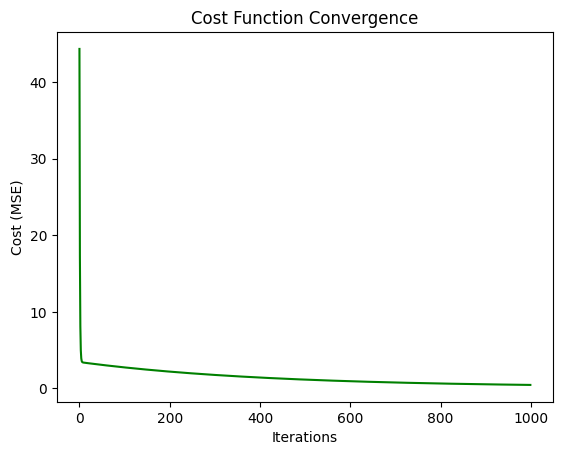

In [27]:
# 7️⃣ Plot cost decrease
# ------------------------------------------------
plt.plot(range(iterations), cost_history, color='green')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost Function Convergence')
plt.show()

In [35]:
# useen data
# ------------------------------------------------
new_x=170
new_y = hypothesis(np.array([[1, new_x]]), final_theta)[0,0]
print(f"Predicted y for x={new_x}: {predicted_y}")

Predicted y for x=170: 21.741102757297085


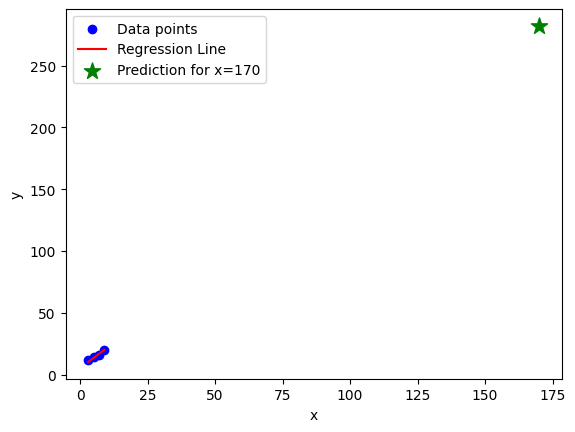

In [36]:
# plot testing data
# ------------------------------------------------
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, hypothesis(X, final_theta), color='red', label='Regression Line')
plt.scatter(new_x, new_y, color='green', marker='*', s=150, label=f'Prediction for x={new_x}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()